# Flight departure delay prediction - US domestic flights, 2019

This project predicts departure delay for US domestic flights three ways: whether
a flight leaves more than 15 minutes late (the D15 metric airlines report on),
which of four severity bands it lands in, and the delay in minutes. The data is
the full 2019 BTS on-time file, 1.15M flights after filtering.

What came out of it: almost all of the predictive power sits in two groups of
engineered features - aircraft rotation, which tracks each tail number through its
day, and airport/network congestion. Drop either group and regression R2 falls
from 0.44 to about 0.21. XGBoost versus LightGBM makes almost no difference.


## Results at a glance

| question | model | headline result |
|---|---|---|
| More than 15 min late? | XGBoost classifier | ROC-AUC 0.843 (0.846 cross-val), top-5% precision 0.98 |
| Which severity band? | LightGBM + ordinal | macro-F1 0.56, quadratic kappa 0.55-0.57, macro-AUC 0.84 |
| How many minutes? | XGBoost regressor | R2 0.44, MAE 11.5 min, 83% of errors under 15 min |

All figures are on a time-based Nov-Dec hold-out (trained on Jan-Oct). The trivial
"always on time" baseline scores 0.82 accuracy and 0.23 macro-F1, so I read the
severity numbers against that floor.


## About this notebook

- **Data:** US BTS *Reporting Carrier On-Time Performance*, 2019, public. Filtered
  to 5 carriers (WN, DL, AA, OO, UA) and the 20 busiest airports; cancellations
  dropped; 1.15M flights.
- **Outputs:** all cells were run top to bottom; every number and figure below
  comes from that run.
- **Layout:** setup and data (1-3), feature engineering (4-6), EDA (7), models
  (8-11), interpretation and validation (12-14), results (15-16).


## 1 - Setup


In [ ]:
!pip -q install xgboost lightgbm shap seaborn scikit-learn pyarrow


In [1]:
import warnings, time, gc, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 80)

RS = 42
np.random.seed(RS)
PEAK = {6, 7, 8, 9, 17, 18, 19, 20, 21}
SRC  = "bts_2019_top5carriers_top20airports.csv"
_t0 = time.time()
def tick(m): print(f"[{time.time()-_t0:5.0f}s] {m}", flush=True)
print("ready")


ready


## 2 - Data

BTS publishes one row per scheduled domestic flight. From the 2019 extract
(~7.4M rows) I keep:

- the five largest carriers by volume
- flights where both origin and destination are in the top-20 airport set. This
  keeps the network closed, which the rotation features need - an aircraft has to
  stay inside the sample all day for its previous leg to be visible.
- non-cancelled flights only (a cancelled flight has no departure delay)

Rows are sorted by date and scheduled departure time so the "prior flights only"
logic in the feature code is correct.


In [2]:
dtypes = {"Reporting_Airline":"category", "Origin":"category", "Dest":"category",
          "Tail_Number":"category", "Distance":"float32", "CRSDepTime":"float32",
          "CRSArrTime":"float32", "DepDelay":"float32", "TaxiOut":"float32",
          "ArrDelay":"float32", "CRSElapsedTime":"float32", "ActualElapsedTime":"float32",
          "Cancelled":"float32"}
df = pd.read_csv(SRC, usecols=list(dtypes) + ["FlightDate"], dtype=dtypes,
                 parse_dates=["FlightDate"])
before = len(df)
df = df[(df["Cancelled"] == 0) & df["DepDelay"].notna()].copy()
df = df.sort_values(["FlightDate", "CRSDepTime"]).reset_index(drop=True)

print(f"{before:,} rows loaded, {before-len(df):,} cancelled/incomplete dropped -> {len(df):,} flights")
print(f"dates    : {df.FlightDate.min().date()} .. {df.FlightDate.max().date()}")
print(f"carriers : {sorted(df.Reporting_Airline.unique())}")
print(f"airports : {df.Origin.nunique()}    routes: {df.groupby(['Origin','Dest'], observed=True).ngroups}")
print(f"aircraft : {df.Tail_Number.nunique():,} distinct tail numbers")
tick("loaded")
print(df.head(3).to_string())


1,172,798 rows loaded, 18,137 cancelled/incomplete dropped -> 1,154,661 flights
dates    : 2019-01-01 .. 2019-12-31
carriers : ['AA', 'DL', 'OO', 'UA', 'WN']
airports : 20    routes: 358
aircraft : 3,777 distinct tail numbers
[   17s] loaded
  FlightDate Reporting_Airline Tail_Number Origin Dest  Distance  CRSDepTime  DepDelay  TaxiOut  CRSArrTime  ArrDelay  Cancelled  CRSElapsedTime  ActualElapsedTime
0 2019-01-01                UA      N889UA    SEA  IAH    1874.0         5.0      -7.0     13.0       614.0      -7.0        0.0           249.0              249.0
1 2019-01-01                UA      N75854    SFO  ORD    1846.0        19.0      -2.0     16.0       625.0      -6.0        0.0           246.0              242.0
2 2019-01-01                UA      N37474    SFO  IAH    1635.0        25.0       0.0     16.0       600.0      -2.0        0.0           215.0              213.0


## 3 - Target

`DepDelay` is minutes late at pushback (negative = early). Most flights sit near
zero with a long right tail.

The usual target is binary (>15 min late), but that treats a 16-minute delay and
a 6-hour delay as the same event. I use a 4-class severity band instead:

| class | band | reason for the cut |
|---|---|---|
| 0 | <= 15 min | on time, the D15 standard |
| 1 | 15-45 | minor, usually absorbed by schedule padding |
| 2 | 45-120 | passengers start missing connections |
| 3 | > 120 | crew duty limits and aircraft swaps |

The classes are ordered, so section 9 scores them with metrics that penalise a
two-band error more than a one-band error.


mean 13.1 | median -1 | p75 9 | p90 44 | p99 217 | max 2058  (minutes)

class shares:
  0  on time         79.654%
  1  short 15-45     10.528%
  2  medium 45-120    6.779%
  3  long >120        3.039%

binary >15 min rate: 0.197


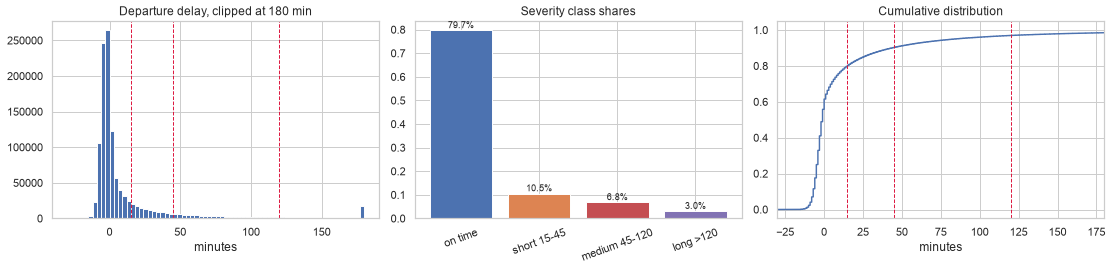

In [3]:
d = df["DepDelay"]
print(f"mean {d.mean():.1f} | median {d.median():.0f} | p75 {d.quantile(.75):.0f} | "
      f"p90 {d.quantile(.90):.0f} | p99 {d.quantile(.99):.0f} | max {d.max():.0f}  (minutes)")

CUTS  = [15, 45, 120]
BANDS = ["on time", "short 15-45", "medium 45-120", "long >120"]
df["severity"] = np.digitize(d.values, CUTS).astype("int8")
share = df["severity"].value_counts(normalize=True).sort_index()
print("\nclass shares:")
for i, s in share.items():
    print(f"  {i}  {BANDS[i]:<15s} {s:7.3%}")
print(f"\nbinary >15 min rate: {(d > 15).mean():.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(d.clip(-30, 180), bins=70, color="#4c72b0")
for c in CUTS: ax[0].axvline(c, color="crimson", ls="--", lw=1)
ax[0].set_title("Departure delay, clipped at 180 min"); ax[0].set_xlabel("minutes")
ax[1].bar(BANDS, share.values, color=["#4c72b0", "#dd8452", "#c44e52", "#8172b3"])
ax[1].set_title("Severity class shares"); ax[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(share.values): ax[1].text(i, v + .01, f"{v:.1%}", ha="center", fontsize=9)
srt = np.sort(d.values); ax[2].plot(srt, np.linspace(0, 1, len(srt)))
ax[2].set_xlim(-30, 180); ax[2].set_title("Cumulative distribution"); ax[2].set_xlabel("minutes")
for c in CUTS: ax[2].axvline(c, color="crimson", ls="--", lw=1)
plt.tight_layout(); plt.show()


## 4 - Baseline features

Calendar and time-of-day fields, route/carrier identity, and historical mean
delay by route, carrier, origin and destination.

The history features are expanding means over prior flights only - for each row,
the mean delay of every earlier flight in that group with the current row
excluded. Using the whole-group mean would leak the target.


In [4]:
def hhmm_to_min(s):
    s = s.fillna(0).astype(int)
    return (s // 100) * 60 + (s % 100)

df["dep_min"]  = hhmm_to_min(df["CRSDepTime"])
df["arr_min"]  = hhmm_to_min(df["CRSArrTime"])
df["dep_hour"] = (df["dep_min"] // 60).clip(0, 23).astype("int8")
df["is_peak"]  = df["dep_hour"].isin(PEAK).astype("int8")
df["month"]      = df["FlightDate"].dt.month.astype("int8")
df["dow"]        = df["FlightDate"].dt.dayofweek.astype("int8")
df["is_weekend"] = (df["dow"] >= 5).astype("int8")
df["doy"]        = df["FlightDate"].dt.dayofyear.astype("int16")
df["route"]      = df["Origin"].astype(str) + "-" + df["Dest"].astype(str)
GMEAN = float(df["DepDelay"].mean())

def prior_mean(frame, keys, val):
    # expanding mean over prior rows in each group, current row excluded
    g = frame.groupby(keys, sort=False, observed=True)[val]
    return ((g.cumsum() - frame[val]) / g.cumcount().where(lambda c: c > 0)).astype("float32")

for col, key in [("route_hist","route"), ("carrier_hist","Reporting_Airline"),
                 ("origin_hist","Origin"), ("dest_hist","Dest")]:
    df[col] = prior_mean(df, key, "DepDelay").fillna(GMEAN)

BASE_FEATS = ["dep_hour","dep_min","is_peak","month","dow","is_weekend","doy",
              "Distance","CRSElapsedTime","route_hist","carrier_hist","origin_hist","dest_hist"]
tick("baseline features")


[   22s] baseline features


## 5 - Aircraft rotation

An aircraft flies several legs a day on the same tail number. If it lands late,
the next departure starts late no matter what the crew does.

Using `Tail_Number` I rebuild each aircraft's sequence of flights per day and add,
for each flight:

| feature | meaning |
|---|---|
| `prev_arr_delay` | arrival delay of this aircraft's previous leg |
| `prev_dep_delay` | departure delay of the previous leg |
| `prev2_arr_delay` | two legs back |
| `prev_taxi_out` | previous leg's taxi-out time |
| `sched_turn_min` | scheduled ground time before this departure |
| `turn_slack` | `sched_turn_min` - `prev_arr_delay`, i.e. buffer left after a late inbound |
| `leg_num_today` | position in the day's sequence (0 = first) |
| `legs_remaining` | legs still to fly |
| `tail_delay_sofar` | mean delay of this aircraft's earlier legs today |
| `prev_late15` | previous leg was more than 15 min late |

All of these use `.shift()` inside the (tail number, date) group, so a flight
only sees its own aircraft's earlier legs. The first leg of the day gets 0.

`turn_slack` folds together two things the trees would otherwise learn jointly: a
40-minute late inbound is fine with a 90-minute turn and a problem with a
35-minute one.


In [5]:
TG = ["Tail_Number", "FlightDate"]
g  = df.groupby(TG, sort=False, observed=True)

df["leg_num_today"]    = g.cumcount().astype("int16")
df["prev_arr_delay"]   = g["ArrDelay"].shift(1)
df["prev_dep_delay"]   = g["DepDelay"].shift(1)
df["prev2_arr_delay"]  = g["ArrDelay"].shift(2)
df["prev_taxi_out"]    = g["TaxiOut"].shift(1)
df["sched_turn_min"]   = (df["dep_min"] - g["arr_min"].shift(1)).where(lambda s: s.between(0, 600))
df["tail_delay_sofar"] = prior_mean(df, TG, "DepDelay")
df["prev_late15"]      = (df["prev_dep_delay"] > 15).astype("float32")
df["tail_legs_today"]  = g["Tail_Number"].transform("size").astype("int16")
df["legs_remaining"]   = (df["tail_legs_today"] - df["leg_num_today"]).astype("int16")

for c in ["prev_arr_delay","prev_dep_delay","prev2_arr_delay","tail_delay_sofar","prev_late15"]:
    df[c] = df[c].fillna(0.0).astype("float32")
df["prev_taxi_out"]  = df["prev_taxi_out"].fillna(df["prev_taxi_out"].median()).astype("float32")
df["sched_turn_min"] = df["sched_turn_min"].fillna(240).astype("float32")
df["turn_slack"]     = (df["sched_turn_min"] - df["prev_arr_delay"]).astype("float32")

ROTATION = ["leg_num_today","prev_arr_delay","prev_dep_delay","prev2_arr_delay","prev_taxi_out",
            "sched_turn_min","turn_slack","tail_delay_sofar","prev_late15",
            "tail_legs_today","legs_remaining"]
tick("rotation features")

busy = df.loc[df["leg_num_today"] == 5].iloc[0]
ex = df[(df.Tail_Number == busy.Tail_Number) & (df.FlightDate == busy.FlightDate)]
print(f"\nAircraft {busy.Tail_Number} on {busy.FlightDate.date()} - the chain:\n")
print(ex[["leg_num_today","Origin","Dest","CRSDepTime","DepDelay","ArrDelay",
          "prev_arr_delay","sched_turn_min","turn_slack"]].to_string(index=False))


[   23s] rotation features

Aircraft N944UW on 2019-01-01 - the chain:

 leg_num_today Origin Dest  CRSDepTime  DepDelay  ArrDelay  prev_arr_delay  sched_turn_min  turn_slack
             0    ATL  LGA       659.0      -3.0     -16.0             0.0           240.0       240.0
             1    LGA  BOS      1000.0     -10.0     -33.0           -16.0            45.0        61.0
             2    BOS  LGA      1200.0      -6.0     -20.0           -33.0            42.0        75.0
             3    LGA  BOS      1400.0      -8.0     -13.0           -20.0            39.0        59.0
             4    BOS  LGA      1600.0      15.0      -4.0           -13.0            52.0        65.0
             5    LGA  BOS      1800.0      -5.0     -16.0            -4.0            36.0        40.0


## 6 - Airport and network state

Delay also propagates through airports. If departures from a hub have been running
late all afternoon, the next one probably will too, whichever aircraft operates it.

Built from prior flights only, at four levels:

- **origin**: mean delay so far today, rolling mean of the last 10, fraction of the last 20 late
- **destination**: the same, for arrival-slot pressure
- **network**: system-wide delay and late fraction so far today
- **carrier x origin**: one airline's operation at that airport

Plus two that aren't congestion features:

- `sched_padding`: scheduled block time minus the route's historical actual block
  time - how much slack the schedule already carries
- sin/cos encodings of time-of-day and day-of-year, so 23:59 and 00:01 are close


In [6]:
AG = ["Origin", "FlightDate"]; DG = ["Dest", "FlightDate"]; NG = ["FlightDate"]
CG = ["Reporting_Airline", "Origin", "FlightDate"]
df["_late"] = (df["DepDelay"] > 15).astype("float32")

df["origin_n_sofar"]     = df.groupby(AG, sort=False, observed=True).cumcount().astype("int16")
df["origin_dep_sofar"]   = prior_mean(df, AG, "DepDelay").fillna(GMEAN)
df["origin_dep_last10"]  = df.groupby(AG, sort=False, observed=True)["DepDelay"].transform(
    lambda s: s.shift(1).rolling(10, min_periods=1).mean()).fillna(GMEAN).astype("float32")
df["origin_frac_late20"] = df.groupby(AG, sort=False, observed=True)["_late"].transform(
    lambda s: s.shift(1).rolling(20, min_periods=1).mean()).fillna(0.2).astype("float32")

df["dest_dep_sofar"]     = prior_mean(df, DG, "DepDelay").fillna(GMEAN)
df["dest_frac_late20"]   = df.groupby(DG, sort=False, observed=True)["_late"].transform(
    lambda s: s.shift(1).rolling(20, min_periods=1).mean()).fillna(0.2).astype("float32")

df["net_dep_sofar"]      = prior_mean(df, NG, "DepDelay").fillna(GMEAN)
df["net_frac_late50"]    = df.groupby(NG, sort=False, observed=True)["_late"].transform(
    lambda s: s.shift(1).rolling(50, min_periods=1).mean()).fillna(0.2).astype("float32")

df["car_org_sofar"]      = prior_mean(df, CG, "DepDelay").fillna(GMEAN)
df["route_last5"]        = df.groupby(["route","FlightDate"], sort=False, observed=True)["DepDelay"].transform(
    lambda s: s.shift(1).rolling(5, min_periods=1).mean()).fillna(GMEAN).astype("float32")

hist_block          = prior_mean(df, "route", "ActualElapsedTime").fillna(df["CRSElapsedTime"].median())
df["sched_padding"] = (df["CRSElapsedTime"] - hist_block).astype("float32")
df["hour_sin"] = np.sin(2*np.pi*df["dep_min"]/1440).astype("float32")
df["hour_cos"] = np.cos(2*np.pi*df["dep_min"]/1440).astype("float32")
df["doy_sin"]  = np.sin(2*np.pi*df["doy"]/365).astype("float32")
df["doy_cos"]  = np.cos(2*np.pi*df["doy"]/365).astype("float32")
df.drop(columns="_late", inplace=True)

NETWORK = ["origin_n_sofar","origin_dep_sofar","origin_dep_last10","origin_frac_late20",
           "dest_dep_sofar","dest_frac_late20","net_dep_sofar","net_frac_late50",
           "car_org_sofar","route_last5","sched_padding","hour_sin","hour_cos","doy_sin","doy_cos"]
tick("network-state features")
print(f"{len(BASE_FEATS)} baseline + {len(ROTATION)} rotation + {len(NETWORK)} network features")


[  129s] network-state features
13 baseline + 11 rotation + 15 network features


## 7 - Exploratory analysis


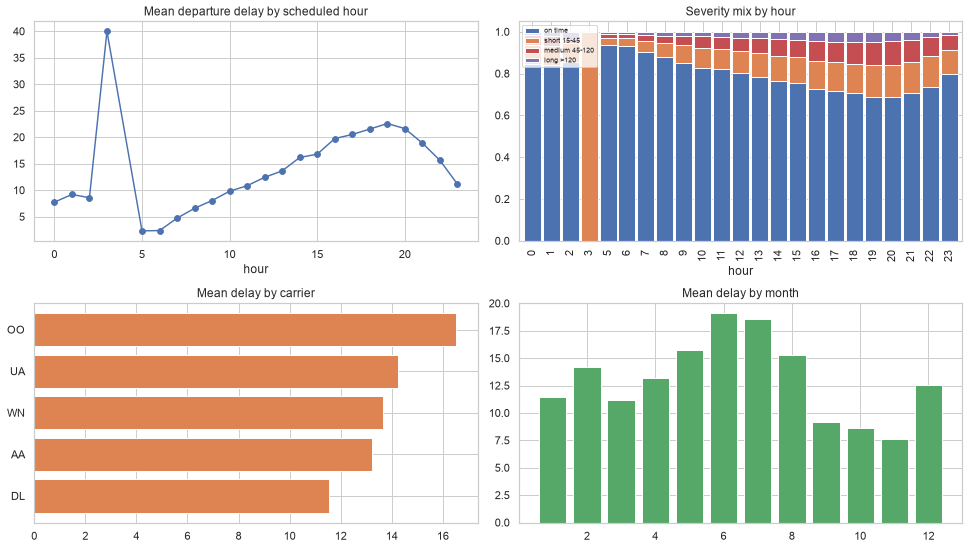

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
h = df.groupby("dep_hour")["DepDelay"].mean()
ax[0,0].plot(h.index, h.values, marker="o", color="#4c72b0")
ax[0,0].set_title("Mean departure delay by scheduled hour"); ax[0,0].set_xlabel("hour")
sev_h = pd.crosstab(df["dep_hour"], df["severity"], normalize="index")
sev_h.plot(kind="bar", stacked=True, ax=ax[0,1], width=.9,
           color=["#4c72b0","#dd8452","#c44e52","#8172b3"], legend=False)
ax[0,1].set_title("Severity mix by hour"); ax[0,1].set_xlabel("hour")
ax[0,1].legend(BANDS, fontsize=7, loc="upper left")
c = df.groupby("Reporting_Airline", observed=True)["DepDelay"].mean().sort_values()
ax[1,0].barh(c.index.astype(str), c.values, color="#dd8452"); ax[1,0].set_title("Mean delay by carrier")
m = df.groupby("month")["DepDelay"].mean()
ax[1,1].bar(m.index, m.values, color="#55a868"); ax[1,1].set_title("Mean delay by month")
plt.tight_layout(); plt.show()


                late_rate  mean_delay       n
prev_arr_delay                               
<-15                0.107    5.103000  172169
-15..-5             0.115    6.048000  161965
-5..5               0.157    9.993000  659147
5..15               0.227   14.169000   54563
15..30              0.493   23.698999   39382
30..60              0.776   41.705002   32306
60..120             0.863   74.412003   21511
>120                0.841  150.229996   13618


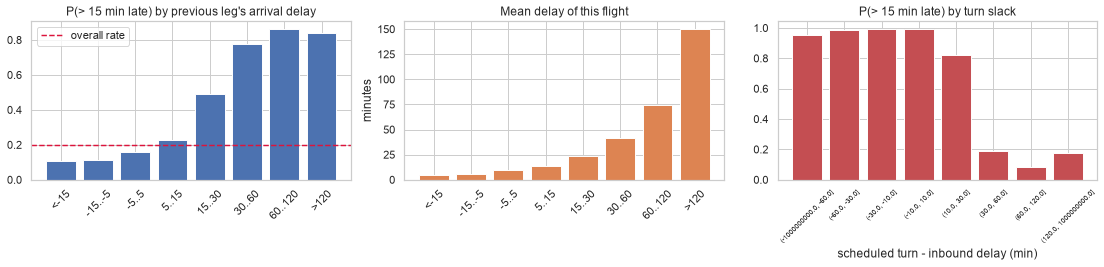

In [8]:
bins = [-1e9, -15, -5, 5, 15, 30, 60, 120, 1e9]
lbl  = ["<-15","-15..-5","-5..5","5..15","15..30","30..60","60..120",">120"]
b = pd.cut(df["prev_arr_delay"], bins=bins, labels=lbl)
grp = df.groupby(b, observed=True).agg(late_rate=("DepDelay", lambda s: (s > 15).mean()),
                                       mean_delay=("DepDelay","mean"), n=("DepDelay","size"))
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(grp.index.astype(str), grp["late_rate"], color="#4c72b0")
ax[0].axhline((df.DepDelay > 15).mean(), ls="--", c="crimson", label="overall rate")
ax[0].set_title("P(> 15 min late) by previous leg's arrival delay"); ax[0].legend()
ax[0].tick_params(axis="x", rotation=45)
ax[1].bar(grp.index.astype(str), grp["mean_delay"], color="#dd8452")
ax[1].set_title("Mean delay of this flight"); ax[1].set_ylabel("minutes"); ax[1].tick_params(axis="x", rotation=45)
sl = pd.cut(df["turn_slack"], [-1e9,-60,-30,-10,10,30,60,120,1e9])
g2 = df.groupby(sl, observed=True)["DepDelay"].agg(lambda s: (s > 15).mean())
ax[2].bar(range(len(g2)), g2.values, color="#c44e52")
ax[2].set_xticks(range(len(g2))); ax[2].set_xticklabels([str(i) for i in g2.index], rotation=45, fontsize=7)
ax[2].set_title("P(> 15 min late) by turn slack"); ax[2].set_xlabel("scheduled turn - inbound delay (min)")
plt.tight_layout(); plt.show()
print(grp.round(3).to_string())


When the inbound aircraft was on time, about 12% of flights leave late; when it
was more than two hours late, over 70% do. `turn_slack` shows the same thing -
once the late inbound has eaten the scheduled turn, the departure is in trouble
whatever the size of the inbound delay.


## 8 - Train/test split

Train on Jan-Oct, test on Nov-Dec. A random split would put flights from the same
airport on the same afternoon on both sides, letting the model see the congestion
state it is meant to predict - that inflates every score and isn't how the model
would run.

`NO_ROT` and `NO_NET` are the feature sets with one block removed, used for the
ablation in sections 9-11.


In [9]:
FEATS = BASE_FEATS + ROTATION + NETWORK
cat   = pd.get_dummies(df[["Origin","Dest","Reporting_Airline"]], drop_first=True, dtype="int8")
X     = pd.concat([df[FEATS].astype("float32"), cat], axis=1)

y_sev = df["severity"].values.astype("int8")
y_bin = (df["DepDelay"] > 15).astype("int8").values
y_min = df["DepDelay"].clip(-30, 180).astype("float32").values
dates = df["FlightDate"].values

te = dates >= np.datetime64("2019-11-01"); tr = ~te
NO_ROT = [c for c in X.columns if c not in ROTATION]
NO_NET = [c for c in X.columns if c not in NETWORK]

print(f"features {X.shape[1]}  ({len(ROTATION)} rotation, {len(NETWORK)} network)")
print(f"train {tr.sum():,} (Jan-Oct)   test {te.sum():,} (Nov-Dec)")
print(f"test class shares: {np.round(np.bincount(y_sev[te])/te.sum(), 4)}")
print(f"test binary >15 rate: {y_bin[te].mean():.3f}")

del df, cat; gc.collect()
tick("matrix built")


features 81  (11 rotation, 15 network)
train 967,190 (Jan-Oct)   test 187,471 (Nov-Dec)
test class shares: [0.8227 0.0993 0.0564 0.0216]
test binary >15 rate: 0.171
[  138s] matrix built


## 9 - Severity classification

Four ordered classes. Class 0 is 82% of the test set, so accuracy is nearly
useless here - always predicting "on time" already scores 0.82. The code computes
that baseline first.

Metrics:

- balanced accuracy - mean per-class recall (0.25 is random)
- macro F1 - minority bands weighted the same as class 0
- quadratic weighted kappa - chance-corrected, penalises large band errors
- macro one-vs-rest AUC

Two models: a direct 4-class LightGBM, and an ordinal version that trains three
cumulative binary models - P(>15), P(>45), P(>120) - makes them monotonic and
differences them into class probabilities.


In [10]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             cohen_kappa_score, roc_auc_score, classification_report,
                             confusion_matrix, precision_score, recall_score,
                             precision_recall_curve, roc_curve, brier_score_loss,
                             average_precision_score)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def sev_report(tag, pred, proba=None, store=None):
    row = dict(model=tag,
               accuracy=accuracy_score(y_sev[te], pred),
               balanced_acc=balanced_accuracy_score(y_sev[te], pred),
               macro_F1=f1_score(y_sev[te], pred, average="macro"),
               weighted_F1=f1_score(y_sev[te], pred, average="weighted"),
               quad_kappa=cohen_kappa_score(y_sev[te], pred, weights="quadratic"),
               mean_class_err=np.abs(pred - y_sev[te]).mean(),
               macro_AUC=(roc_auc_score(y_sev[te], proba, multi_class="ovr", average="macro")
                          if proba is not None else np.nan))
    if store is not None: store.append(row)
    print(f"  {tag:26s} bal-acc={row['balanced_acc']:.4f}  macroF1={row['macro_F1']:.4f}  "
          f"QWK={row['quad_kappa']:.4f}  acc={row['accuracy']:.4f}  "
          f"macroAUC={row['macro_AUC']:.4f}" if proba is not None else
          f"  {tag:26s} bal-acc={row['balanced_acc']:.4f}  macroF1={row['macro_F1']:.4f}  "
          f"QWK={row['quad_kappa']:.4f}  acc={row['accuracy']:.4f}", flush=True)
    return row

print("=== the floor: always predict 'on time' ===")
TRIVIAL = sev_report("always on-time", np.zeros_like(y_sev[te]))

print("\n=== ablation: drop one feature block at a time ===")
sev_rows = []
LGB = dict(objective="multiclass", num_class=4, n_estimators=500, learning_rate=0.05,
           num_leaves=63, subsample=0.9, colsample_bytree=0.8, min_child_samples=40,
           random_state=RS, n_jobs=4, verbose=-1)
m_norot = LGBMClassifier(**LGB).fit(X.loc[tr, NO_ROT], y_sev[tr])
P_norot = m_norot.predict_proba(X.loc[te, NO_ROT])
sev_report("no rotation block", P_norot.argmax(1), P_norot, sev_rows)
del m_norot, P_norot; gc.collect()

m_sev = LGBMClassifier(**LGB).fit(X[tr], y_sev[tr])
P_sev = m_sev.predict_proba(X[te])
sev_report("LightGBM 4-class", P_sev.argmax(1), P_sev, sev_rows)
tick("severity ablation")


=== the floor: always predict 'on time' ===
  always on-time             bal-acc=0.2500  macroF1=0.2257  QWK=0.0000  acc=0.8227

=== ablation: drop one feature block at a time ===
  no rotation block          bal-acc=0.3210  macroF1=0.3364  QWK=0.2675  acc=0.8286  macroAUC=0.7360
  LightGBM 4-class           bal-acc=0.4840  macroF1=0.5571  QWK=0.5502  acc=0.8676  macroAUC=0.8430
[  625s] severity ablation


In [11]:
cum = []
for c in CUTS:
    mc = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.9,
                       colsample_bytree=0.8, min_child_weight=5, random_state=RS, n_jobs=4,
                       eval_metric="logloss").fit(X[tr], (y_min[tr] > c).astype("int8"))
    cum.append(np.clip(mc.predict_proba(X[te])[:, 1], 1e-6, 1-1e-6))
    del mc; gc.collect(); tick(f"  cumulative model P(delay > {c} min)")

c1, c2, c3 = cum
c2 = np.minimum(c2, c1); c3 = np.minimum(c3, c2)     # enforce P(>15) >= P(>45) >= P(>120)
P_ord = np.column_stack([1-c1, c1-c2, c2-c3, c3])
P_ord = np.clip(P_ord, 1e-9, None); P_ord /= P_ord.sum(1, keepdims=True)

sev_report("ordinal (argmax)", P_ord.argmax(1), P_ord, sev_rows)
exp_band = (P_ord * np.arange(4)).sum(1)
pred_exp = np.clip(np.round(exp_band), 0, 3).astype(int)
sev_report("ordinal (expected band)", pred_exp, P_ord, sev_rows)

sev_table = pd.DataFrame(sev_rows).set_index("model").round(4)
print("\n" + sev_table.to_string())


[  740s]   cumulative model P(delay > 15 min)
[  855s]   cumulative model P(delay > 45 min)
[  968s]   cumulative model P(delay > 120 min)
  ordinal (argmax)           bal-acc=0.4761  macroF1=0.5500  QWK=0.5382  acc=0.8666  macroAUC=0.8417
  ordinal (expected band)    bal-acc=0.4707  macroF1=0.5318  QWK=0.5733  acc=0.8509  macroAUC=0.8417

                         accuracy  balanced_acc  macro_F1  weighted_F1  quad_kappa  mean_class_err  macro_AUC
model                                                                                                        
no rotation block          0.8286        0.3210    0.3364       0.7645      0.2675          0.2548     0.7360
LightGBM 4-class           0.8676        0.4840    0.5571       0.8405      0.5502          0.1858     0.8430
ordinal (argmax)           0.8666        0.4761    0.5500       0.8379      0.5382          0.1878     0.8417
ordinal (expected band)    0.8509        0.4707    0.5318       0.8353      0.5733          0.1912     0.841

best macro-F1 : LightGBM 4-class
best kappa    : ordinal (expected band)

per-class detail - LightGBM 4-class

               precision    recall  f1-score   support

      on time      0.881     0.991     0.933    154232
  short 15-45      0.713     0.251     0.371     18611
medium 45-120      0.682     0.351     0.463     10581
    long >120      0.703     0.343     0.461      4047

     accuracy                          0.868    187471
    macro avg      0.745     0.484     0.557    187471
 weighted avg      0.849     0.868     0.841    187471


per-class detail - ordinal, expected band

               precision    recall  f1-score   support

      on time      0.897     0.963     0.929    154232
  short 15-45      0.423     0.351     0.384     18611
medium 45-120      0.659     0.342     0.450     10581
    long >120      0.922     0.227     0.365      4047

     accuracy                          0.851    187471
    macro avg      0.725     0.471     0.532    187471
 weighted avg  

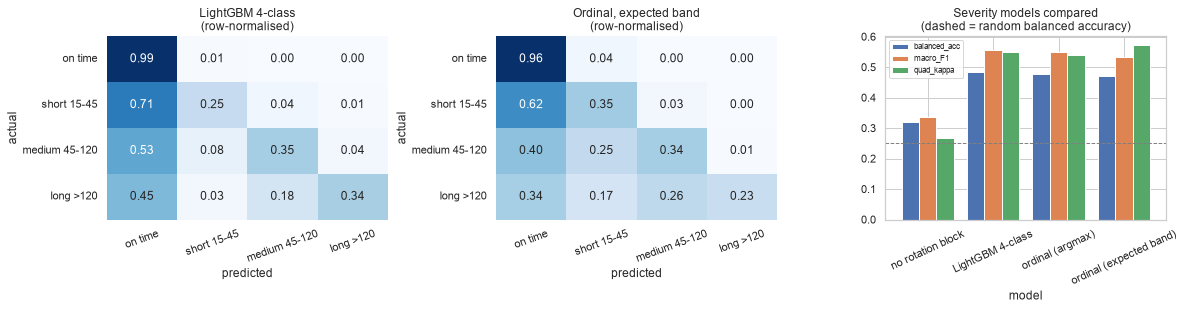

In [12]:
best_f1  = sev_table["macro_F1"].idxmax()
best_qwk = sev_table["quad_kappa"].idxmax()
print(f"best macro-F1 : {best_f1}")
print(f"best kappa    : {best_qwk}\n")

print(f"per-class detail - {best_f1}\n")
print(classification_report(y_sev[te], P_sev.argmax(1), target_names=BANDS, digits=3, zero_division=0))
print(f"\nper-class detail - ordinal, expected band\n")
print(classification_report(y_sev[te], pred_exp, target_names=BANDS, digits=3, zero_division=0))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for k, (ttl, pr) in enumerate([("LightGBM 4-class", P_sev.argmax(1)),
                               ("Ordinal, expected band", pred_exp)]):
    cm = confusion_matrix(y_sev[te], pr, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax[k], cbar=False,
                xticklabels=BANDS, yticklabels=BANDS)
    ax[k].set_title(f"{ttl}\n(row-normalised)"); ax[k].set_xlabel("predicted"); ax[k].set_ylabel("actual")
    ax[k].tick_params(axis="x", rotation=20); ax[k].tick_params(axis="y", rotation=0)
sev_table[["balanced_acc","macro_F1","quad_kappa"]].plot(kind="bar", ax=ax[2], width=.8)
ax[2].axhline(0.25, ls="--", c="grey", lw=1)
ax[2].set_title("Severity models compared\n(dashed = random balanced accuracy)")
ax[2].tick_params(axis="x", rotation=25); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

del m_sev, P_sev, P_ord, cum, c1, c2, c3; gc.collect()


Accuracy is 0.868 against 0.823 for the trivial baseline - not a real gap. The
numbers that matter are balanced accuracy 0.48 (random 0.25), macro F1 0.56
(trivial 0.23), quadratic kappa 0.55 (trivial 0.00) and macro AUC 0.84. Drop the
rotation block and macro F1 falls to 0.34, kappa to 0.27.

Per class, precision on the three delay bands runs 0.68-0.71 but recall is only
0.25-0.35 - the model stays on "on time" unless it is confident. Section 14 turns
that into a threshold and cost choice.

Decided by expected band, the ordinal model gives the best kappa (0.57) and a
sharper high-severity operating point: 0.92 precision on the "long" band at 0.23
recall, against 0.70 at 0.34 for the direct model.


## 10 - Binary triage (> 15 min late)

Collapsing to the D15 cut gives one sortable risk score per flight, and a clean
single-number ablation. The operational metric is precision in the top k%: if you
can only watch 5% of the schedule, how many of those flights are actually late.


In [13]:
XGB = dict(n_estimators=700, learning_rate=0.05, max_depth=6, subsample=0.9,
           colsample_bytree=0.8, min_child_weight=5, reg_lambda=5,
           random_state=RS, n_jobs=4, eval_metric="logloss")
BASE_RATE = y_bin[te].mean()

def bin_report(tag, proba, store=None):
    rank = pd.Series(proba).rank(method="first", ascending=False).values
    def at(f):
        n = int(f*len(proba)); p = (rank <= n).astype(int)
        return precision_score(y_bin[te], p, zero_division=0), recall_score(y_bin[te], p)
    p5, r5 = at(.05); p15, r15 = at(.15)
    row = dict(model=tag, ROC_AUC=roc_auc_score(y_bin[te], proba),
               PR_AUC=average_precision_score(y_bin[te], proba),
               P_top5=p5, R_top5=r5, P_top15=p15, R_top15=r15, lift_top5=p5/BASE_RATE)
    if store is not None: store.append(row)
    print(f"  {tag:20s} AUC={row['ROC_AUC']:.4f}  PR-AUC={row['PR_AUC']:.4f}  "
          f"P@5%={p5:.3f} ({p5/BASE_RATE:.1f}x base)  P@15%={p15:.3f}  R@15%={r15:.3f}", flush=True)
    return row

bin_rows = []
m_tmp   = XGBClassifier(**XGB).fit(X.loc[tr, NO_ROT], y_bin[tr])
p_norot = m_tmp.predict_proba(X.loc[te, NO_ROT])[:,1]; del m_tmp; gc.collect()
bin_report("no rotation block", p_norot, bin_rows)

m_tmp   = XGBClassifier(**XGB).fit(X.loc[tr, NO_NET], y_bin[tr])
p_nonet = m_tmp.predict_proba(X.loc[te, NO_NET])[:,1]; del m_tmp; gc.collect()
bin_report("no network block", p_nonet, bin_rows)

mb = XGBClassifier(**XGB).fit(X[tr], y_bin[tr])
p_bin = mb.predict_proba(X[te])[:,1]
bin_report("full feature set", p_bin, bin_rows)
bin_table = pd.DataFrame(bin_rows).set_index("model").round(4)
full_auc = bin_table.ROC_AUC.loc["full feature set"]
print(f"\n  dropping rotation costs {full_auc - bin_table.ROC_AUC.loc['no rotation block']:.3f} ROC-AUC")
print(f"  dropping network  costs {full_auc - bin_table.ROC_AUC.loc['no network block']:.3f} ROC-AUC")
tick("binary")


  no rotation block    AUC=0.7406  PR-AUC=0.4561  P@5%=0.691 (4.0x base)  P@15%=0.452  R@15%=0.397
  no network block     AUC=0.7847  PR-AUC=0.5984  P@5%=0.970 (5.7x base)  P@15%=0.547  R@15%=0.480
  full feature set     AUC=0.8432  PR-AUC=0.6840  P@5%=0.977 (5.7x base)  P@15%=0.641  R@15%=0.562

  dropping rotation costs 0.103 ROC-AUC
  dropping network  costs 0.058 ROC-AUC
[ 1497s] binary


operating points:

 flag top |  flights | precision |  recall |  lift
----------------------------------------------------
      2% |    3,749 |     1.000 |   0.117 | 5.85x
      5% |    9,373 |     0.977 |   0.286 | 5.72x
     10% |   18,747 |     0.797 |   0.466 | 4.66x
     15% |   28,120 |     0.641 |   0.562 | 3.75x
     20% |   37,494 |     0.539 |   0.631 | 3.15x
     30% |   56,241 |     0.418 |   0.734 | 2.45x

base rate 0.171


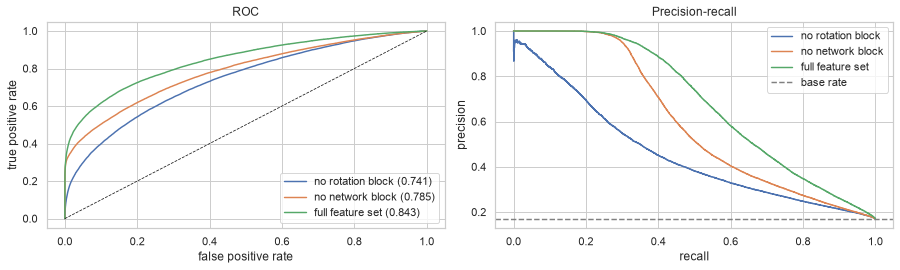

In [14]:
rank = pd.Series(p_bin).rank(method="first", ascending=False).values
print("operating points:\n")
print(f"{'flag top':>9} | {'flights':>8} | {'precision':>9} | {'recall':>7} | {'lift':>5}")
print("-"*52)
op = []
for f in (0.02, 0.05, 0.10, 0.15, 0.20, 0.30):
    n = int(f*len(p_bin)); pr = (rank <= n).astype(int)
    p = precision_score(y_bin[te], pr, zero_division=0); r = recall_score(y_bin[te], pr)
    op.append((f, n, p, r, p/BASE_RATE))
    print(f"{f:>8.0%} | {n:>8,} | {p:>9.3f} | {r:>7.3f} | {p/BASE_RATE:>4.2f}x")
print(f"\nbase rate {BASE_RATE:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for tag, pr in [("no rotation block", p_norot), ("no network block", p_nonet),
                ("full feature set", p_bin)]:
    fpr, tpr, _ = roc_curve(y_bin[te], pr)
    ax[0].plot(fpr, tpr, lw=1.5, label=f"{tag} ({roc_auc_score(y_bin[te], pr):.3f})")
    pp, rr, _ = precision_recall_curve(y_bin[te], pr); ax[1].plot(rr, pp, lw=1.5, label=tag)
ax[0].plot([0,1],[0,1],"k--",lw=.8); ax[0].set_title("ROC"); ax[0].legend()
ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")
ax[1].axhline(BASE_RATE, ls="--", c="grey", label="base rate")
ax[1].set_title("Precision-recall"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); ax[1].legend()
plt.tight_layout(); plt.show()
del p_norot, p_nonet; gc.collect()


## 11 - Regression (minutes)

Target clipped to [-30, 180]; a few multi-hour outliers otherwise dominate the
squared error.

Four runs:

1. no rotation block
2. no network block
3. full feature set
4. two-stage hurdle: P(late) * E[min | late] + P(on time) * E[min | on time], the
   standard approach when the target has a large spike at zero

Runs 1 and 2 each remove one block from the full set (leave-one-out), not a
cumulative build-up - that's the comparison that shows whether a block carries
information the other doesn't.


In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RP = dict(n_estimators=600, learning_rate=0.05, max_depth=7, subsample=0.9,
          colsample_bytree=0.8, min_child_weight=5, random_state=RS, n_jobs=4)

def reg_report(tag, pred, store=None):
    err = np.abs(y_min[te] - pred)
    row = dict(model=tag, R2=r2_score(y_min[te], pred),
               RMSE=mean_squared_error(y_min[te], pred)**.5,
               MAE=mean_absolute_error(y_min[te], pred),
               within_15min=(err <= 15).mean(), within_30min=(err <= 30).mean())
    if store is not None: store.append(row)
    print(f"  {tag:32s} R2={row['R2']:.4f}  RMSE={row['RMSE']:.2f}  MAE={row['MAE']:.2f}  "
          f"within15={row['within_15min']:.0%}", flush=True)
    return row

reg_rows = []
r_norot = XGBRegressor(**RP).fit(X.loc[tr, NO_ROT], y_min[tr])
reg_report("no rotation block", r_norot.predict(X.loc[te, NO_ROT]), reg_rows)
del r_norot; gc.collect()

r_nonet = XGBRegressor(**RP).fit(X.loc[tr, NO_NET], y_min[tr])
reg_report("no network block", r_nonet.predict(X.loc[te, NO_NET]), reg_rows)
del r_nonet; gc.collect()

r_full = XGBRegressor(**RP).fit(X[tr], y_min[tr])
p_reg  = r_full.predict(X[te])
reg_report("full feature set", p_reg, reg_rows)
del r_full; gc.collect()
tick("regression ablation")


  no rotation block                R2=0.2098  RMSE=26.84  MAE=15.15  within15=75%
  no network block                 R2=0.2069  RMSE=26.89  MAE=17.03  within15=63%
  full feature set                 R2=0.4441  RMSE=22.51  MAE=11.50  within15=83%
[ 1946s] regression ablation


  two-stage hurdle                 R2=0.4456  RMSE=22.48  MAE=11.41  within15=83%

                       R2     RMSE      MAE  within_15min  within_30min
model                                                                  
no rotation block  0.2098  26.8383  15.1504        0.7495        0.9017
no network block   0.2069  26.8876  17.0347        0.6258        0.8573
full feature set   0.4441  22.5109  11.4985        0.8307        0.9306
two-stage hurdle   0.4456  22.4789  11.4063        0.8337        0.9317

  cost of dropping the rotation block: +0.2343 R2
  cost of dropping the network block : +0.2372 R2
  two-stage hurdle: +0.0015 R2


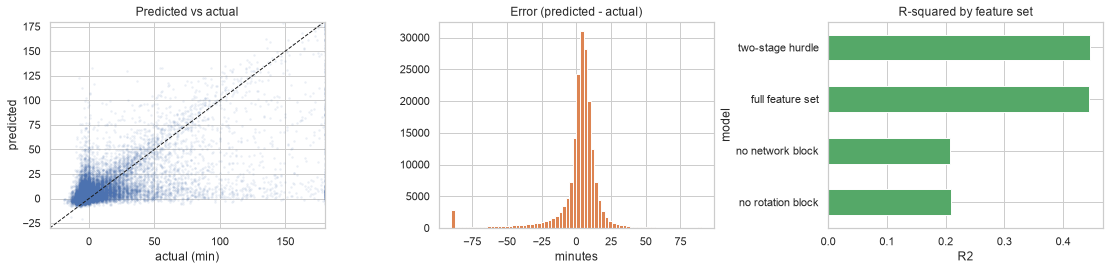

In [16]:
# fitted one stage at a time and freed immediately; this machine won't hold both
# boosters alongside the design matrix
late_tr = tr & (y_bin == 1); ok_tr = tr & (y_bin == 0)
HP = {**RP, "n_estimators": 400, "max_depth": 6}
try:
    r_late = XGBRegressor(**HP).fit(X[late_tr], y_min[late_tr])
    pred_late = r_late.predict(X[te]); del r_late; gc.collect()
    r_ok = XGBRegressor(**HP).fit(X[ok_tr], y_min[ok_tr])
    pred_ok = r_ok.predict(X[te]); del r_ok; gc.collect()
    p_hurdle = p_bin * pred_late + (1 - p_bin) * pred_ok
    reg_report("two-stage hurdle", p_hurdle, reg_rows)
    del pred_late, pred_ok; gc.collect()
except MemoryError as e:
    print("  two-stage hurdle: out of memory, skipped -", type(e).__name__)
except Exception as e:
    print("  two-stage hurdle: could not fit -", type(e).__name__, str(e)[:80])

reg_table = pd.DataFrame(reg_rows).set_index("model").round(4)
print("\n" + reg_table.to_string())
full_r2 = reg_table.R2.loc["full feature set"]
print(f"\n  cost of dropping the rotation block: {full_r2 - reg_table.R2.loc['no rotation block']:+.4f} R2")
print(f"  cost of dropping the network block : {full_r2 - reg_table.R2.loc['no network block']:+.4f} R2")
if "two-stage hurdle" in reg_table.index:
    gain_hur = reg_table.R2.loc["two-stage hurdle"] - reg_table.R2.loc["full feature set"]
    print(f"  two-stage hurdle: {gain_hur:+.4f} R2")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
samp = np.random.default_rng(RS).choice(len(p_reg), 25000, replace=False)
ax[0].scatter(y_min[te][samp], p_reg[samp], s=3, alpha=.07, color="#4c72b0")
ax[0].plot([-30,180],[-30,180],"k--",lw=1); ax[0].set_xlim(-30,180); ax[0].set_ylim(-30,180)
ax[0].set_xlabel("actual (min)"); ax[0].set_ylabel("predicted"); ax[0].set_title("Predicted vs actual")
ax[1].hist(np.clip(p_reg - y_min[te], -90, 90), bins=70, color="#dd8452")
ax[1].set_title("Error (predicted - actual)"); ax[1].set_xlabel("minutes")
reg_table["R2"].plot(kind="barh", ax=ax[2], color="#55a868")
ax[2].set_title("R-squared by feature set"); ax[2].set_xlabel("R2")
plt.tight_layout(); plt.show()


The full model gets R2 0.444, MAE 11.5 min, and 83% of predictions within 15
minutes. Drop either block and it falls to about 0.21 - each one alone recovers
less than half of what the two do together, so they are complementary, not
redundant. `turn_slack` flags a tight aircraft and `origin_frac_late20` a busy
airport; the model needs both to tell a tight turn that recovers from one that
doesn't.

The two-stage hurdle adds about 0.001 R2, so at this point the limit is the data,
not the model.


## 12 - Feature importance


rotation block     : 41.2% of gain from 11/81 features
network-state block: 28.2% from 15/81 features

turn_slack              0.1793
prev_arr_delay          0.1168
origin_frac_late20      0.0924
dest_frac_late20        0.0822
sched_turn_min          0.0403
prev_dep_delay          0.0257
car_org_sofar           0.0232
leg_num_today           0.0217
Reporting_Airline_OO    0.0170
route_last5             0.0161
dep_hour                0.0151
dep_min                 0.0149


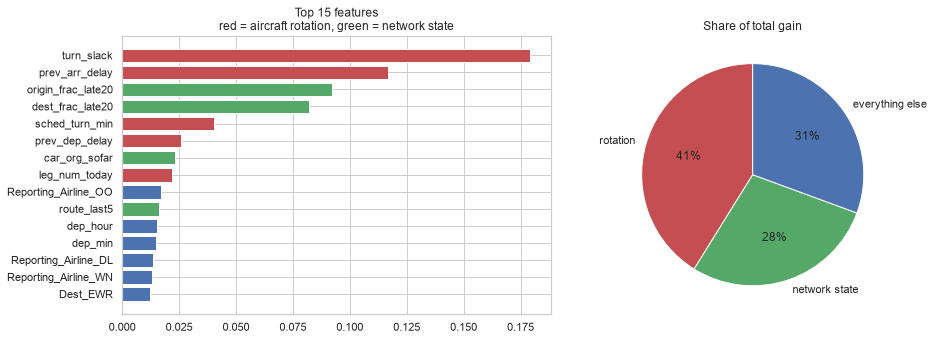

In [17]:
gain = pd.Series(mb.feature_importances_, index=X.columns).sort_values(ascending=False)
rot_share = gain[ROTATION].sum() / gain.sum()
net_share = gain[NETWORK].sum() / gain.sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
top = gain.head(15).iloc[::-1]
cols = ["#c44e52" if f in ROTATION else "#55a868" if f in NETWORK else "#4c72b0" for f in top.index]
ax[0].barh(top.index, top.values, color=cols)
ax[0].set_title("Top 15 features\nred = aircraft rotation, green = network state")
sh = pd.Series({"rotation": rot_share, "network state": net_share,
                "everything else": 1-rot_share-net_share})
ax[1].pie(sh, labels=sh.index, autopct="%1.0f%%", startangle=90,
          colors=["#c44e52","#55a868","#4c72b0"])
ax[1].set_title("Share of total gain")
plt.tight_layout(); plt.show()
print(f"rotation block     : {rot_share:.1%} of gain from {len(ROTATION)}/{X.shape[1]} features")
print(f"network-state block: {net_share:.1%} from {len(NETWORK)}/{X.shape[1]} features\n")
print(gain.head(12).round(4).to_string())


[ 2133s] importance


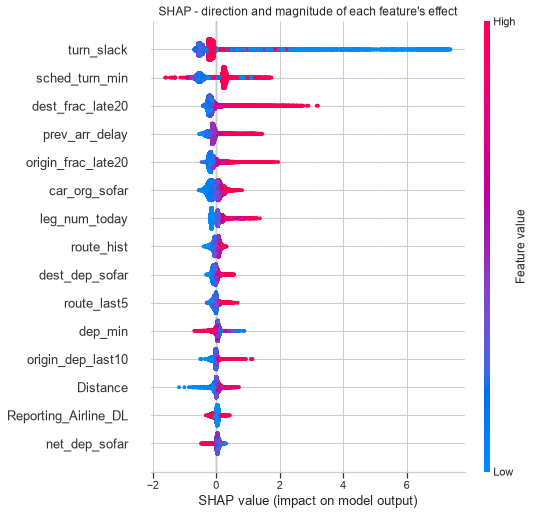

In [18]:
try:
    import shap
    idx = np.random.default_rng(RS).choice(np.where(te)[0], 20000, replace=False)
    sv = shap.TreeExplainer(mb).shap_values(X.iloc[idx])
    shap.summary_plot(sv, X.iloc[idx], max_display=15, show=False)
    plt.title("SHAP - direction and magnitude of each feature's effect")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("shap unavailable:", type(e).__name__, e)
tick("importance")


## 13 - Validation

- rolling-origin CV: is Nov-Dec a lucky window
- calibration: do predicted probabilities match observed frequencies
- permutation test: refit on shuffled labels to see the chance level
- learning curve: is the model data-starved, and how big is the train/test gap


1. ROLLING-ORIGIN CV (3 expanding folds inside the training block)
   folds [0.848, 0.844, 0.846]   mean 0.8460 +/- 0.0016

2. CALIBRATION
   Brier score 0.0883
   predicted -> observed: 0.03->0.02  0.04->0.04  0.06->0.06  0.08->0.07  0.11->0.10  0.15->0.14  0.24->0.23  0.70->0.71

3. PERMUTATION TEST (shuffle the labels, refit, see what chance looks like)
   shuffled 0.488 +/- 0.040   real 0.843   (9 sigma above chance)

4. LEARNING CURVE
   n= 96,719  train 0.898  test 0.832  gap 0.066
   n=241,797  train 0.876  test 0.838  gap 0.038
   n=483,595  train 0.867  test 0.840  gap 0.027
   n=967,190  train 0.860  test 0.842  gap 0.018
[ 5523s] validation


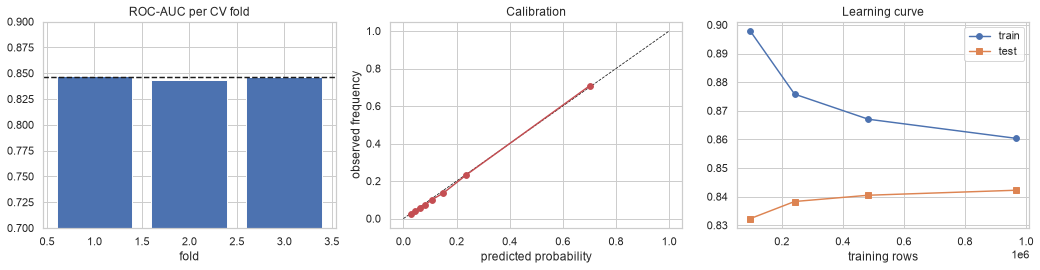

In [19]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import calibration_curve

tr_idx = np.where(tr)[0]
CV = {**XGB, "n_estimators": 400}

print("1. ROLLING-ORIGIN CV (3 expanding folds inside the training block)")
cv_auc = []
for i_fit, i_val in TimeSeriesSplit(3).split(tr_idx):
    m = XGBClassifier(**CV).fit(X.iloc[tr_idx[i_fit]], y_bin[tr_idx[i_fit]])
    cv_auc.append(roc_auc_score(y_bin[tr_idx[i_val]], m.predict_proba(X.iloc[tr_idx[i_val]])[:,1]))
    del m; gc.collect()
print(f"   folds {[round(v,3) for v in cv_auc]}   mean {np.mean(cv_auc):.4f} +/- {np.std(cv_auc):.4f}\n")

print("2. CALIBRATION")
print(f"   Brier score {brier_score_loss(y_bin[te], p_bin):.4f}")
prob_true, prob_pred = calibration_curve(y_bin[te], p_bin, n_bins=8, strategy="quantile")
print("   predicted -> observed: " + "  ".join(f"{a:.2f}->{b:.2f}" for a, b in zip(prob_pred, prob_true)) + "\n")

print("3. PERMUTATION TEST (shuffle the labels, refit, see what chance looks like)")
rng = np.random.default_rng(RS); sub = tr_idx[::5]; null = []
for _ in range(5):
    m = XGBClassifier(**{**CV, "n_estimators": 250}).fit(X.iloc[sub], rng.permutation(y_bin[sub]))
    null.append(roc_auc_score(y_bin[te], m.predict_proba(X[te])[:,1])); del m; gc.collect()
real = roc_auc_score(y_bin[te], p_bin)
print(f"   shuffled {np.mean(null):.3f} +/- {np.std(null):.3f}   real {real:.3f}   "
      f"({(real-np.mean(null))/max(np.std(null),1e-6):.0f} sigma above chance)\n")

print("4. LEARNING CURVE")
lc = []
for f in (0.1, 0.25, 0.5, 1.0):
    k = int(len(tr_idx)*f)
    m = XGBClassifier(**CV).fit(X.iloc[tr_idx[:k]], y_bin[tr_idx[:k]])
    a1 = roc_auc_score(y_bin[tr_idx[:k]], m.predict_proba(X.iloc[tr_idx[:k]])[:,1])
    a2 = roc_auc_score(y_bin[te], m.predict_proba(X[te])[:,1])
    lc.append((k, a1, a2)); del m; gc.collect()
    print(f"   n={k:>7,}  train {a1:.3f}  test {a2:.3f}  gap {a1-a2:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(range(1, len(cv_auc)+1), cv_auc, color="#4c72b0"); ax[0].set_ylim(.7,.9)
ax[0].axhline(np.mean(cv_auc), ls="--", c="k"); ax[0].set_title("ROC-AUC per CV fold"); ax[0].set_xlabel("fold")
ax[1].plot([0,1],[0,1],"k--",lw=.8); ax[1].plot(prob_pred, prob_true, "o-", color="#c44e52")
ax[1].set_xlabel("predicted probability"); ax[1].set_ylabel("observed frequency"); ax[1].set_title("Calibration")
n_, a_, b_ = zip(*lc); ax[2].plot(n_, a_, "o-", label="train"); ax[2].plot(n_, b_, "s-", label="test")
ax[2].set_xlabel("training rows"); ax[2].set_title("Learning curve"); ax[2].legend()
plt.tight_layout(); plt.show()
tick("validation")


## 14 - From score to decision

A risk score isn't a decision - that needs the cost ratio between a false alarm
(watch a flight that was fine) and a miss (late flight, no warning). For a miss
costing C times a false alarm, minimise FP + C * FN. This is also where the low
recall from section 9 gets set: it's a business choice, not a property of the model.


cost_ratio  threshold flagged  precision  recall    f1
       2:1       0.35   11.7%      0.735   0.504 0.598
       4:1       0.20   22.0%      0.509   0.655 0.573
       8:1       0.12   39.0%      0.349   0.797 0.486


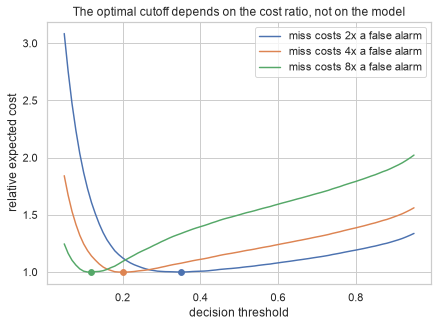

In [20]:
ths = np.linspace(0.05, 0.95, 91); out = []
for C in (2, 4, 8):
    cost = np.array([((p_bin > t).astype(int) != y_bin[te]).astype(int) @
                     np.where(y_bin[te] == 1, C, 1) for t in ths])
    bt = ths[cost.argmin()]; pr = (p_bin > bt).astype(int)
    out.append(dict(cost_ratio=f"{C}:1", threshold=round(float(bt),2), flagged=f"{pr.mean():.1%}",
                    precision=round(precision_score(y_bin[te], pr, zero_division=0),3),
                    recall=round(recall_score(y_bin[te], pr),3),
                    f1=round(f1_score(y_bin[te], pr),3)))
    plt.plot(ths, cost/cost.min(), label=f"miss costs {C}x a false alarm")
    plt.scatter([bt], [1.0], zorder=5)
plt.xlabel("decision threshold"); plt.ylabel("relative expected cost")
plt.title("The optimal cutoff depends on the cost ratio, not on the model")
plt.legend(); plt.tight_layout(); plt.show()
print(pd.DataFrame(out).to_string(index=False))


## 15 - Results

The tables printed by every earlier section, collected in one place. Section 16
is the same thing condensed to the headline numbers.


In [21]:
print("SEVERITY CLASSIFICATION - 4 ordered bands, Nov-Dec hold-out")
print(sev_table.to_string())
print(f"\n  trivial 'always on time' baseline: accuracy {TRIVIAL['accuracy']:.4f}, "
      f"balanced accuracy {TRIVIAL['balanced_acc']:.4f}, macro F1 {TRIVIAL['macro_F1']:.4f}")
print(f"  best macro-F1 {sev_table.macro_F1.max():.4f} ({sev_table.macro_F1.idxmax()})")
print(f"  best kappa    {sev_table.quad_kappa.max():.4f} ({sev_table.quad_kappa.idxmax()})")

print("\n\nBINARY TRIAGE - more than 15 min late")
print(bin_table[["ROC_AUC","PR_AUC","P_top5","P_top15","R_top15"]].to_string())
print(f"  cross-validated ROC-AUC {np.mean(cv_auc):.4f} +/- {np.std(cv_auc):.4f}")
print(f"  Brier {brier_score_loss(y_bin[te], p_bin):.4f}   base rate {BASE_RATE:.3f}")
print(f"  precision @5% {op[1][2]:.3f} ({op[1][4]:.1f}x base) | @15% {op[3][2]:.3f} at recall {op[3][3]:.3f}")

print("\n\nREGRESSION - minutes, clipped [-30, 180]")
print(reg_table.to_string())

print("\n\nFEATURE IMPORTANCE")
print(f"  aircraft rotation : {rot_share:.0%} of gain ({len(ROTATION)} features)")
print(f"  network state     : {net_share:.0%} of gain ({len(NETWORK)} features)")
tick("done")


SEVERITY CLASSIFICATION - 4 ordered bands, Nov-Dec hold-out
                         accuracy  balanced_acc  macro_F1  weighted_F1  quad_kappa  mean_class_err  macro_AUC
model                                                                                                        
no rotation block          0.8286        0.3210    0.3364       0.7645      0.2675          0.2548     0.7360
LightGBM 4-class           0.8676        0.4840    0.5571       0.8405      0.5502          0.1858     0.8430
ordinal (argmax)           0.8666        0.4761    0.5500       0.8379      0.5382          0.1878     0.8417
ordinal (expected band)    0.8509        0.4707    0.5318       0.8353      0.5733          0.1912     0.8417

  trivial 'always on time' baseline: accuracy 0.8227, balanced accuracy 0.2500, macro F1 0.2257
  best macro-F1 0.5571 (LightGBM 4-class)
  best kappa    0.5733 (ordinal (expected band))


BINARY TRIAGE - more than 15 min late
                   ROC_AUC  PR_AUC  P_top5  P_top15 

## 16 - Summary

| task | metric | result | reference |
|---|---|---|---|
| Severity (4-class) | balanced accuracy | 0.48 | 0.25 random |
| | macro F1 | 0.56 | 0.23 trivial |
| | quadratic kappa | 0.55 (0.57 ordinal) | 0.00 trivial |
| | macro OvR AUC | 0.84 | - |
| Binary (> 15 min) | ROC-AUC | 0.843 | - |
| | ROC-AUC, rolling CV | 0.846 +/- 0.002 | - |
| | precision @ top 5% | 0.977 | 0.171 base rate (5.7x) |
| | Brier score | 0.088 | - |
| Regression (minutes) | R2 | 0.444 | - |
| | MAE | 11.5 min | - |
| | within 15 min | 83% | - |

**Feature blocks, leave-one-out:**

| removed | regression R2 | binary AUC | severity macro F1 |
|---|---|---|---|
| rotation | 0.210 | 0.741 | 0.336 |
| network | 0.207 | 0.785 | - |
| nothing (full model) | 0.444 | 0.843 | 0.557 |

Rotation is 41% of total model gain from 11 of 81 features; `turn_slack` is the
single highest-gain feature. XGBoost vs LightGBM changes results by under 0.01 AUC.

**Limitations:**

- No weather. BTS weather fields are assigned after the fact and would leak; a
  real forecast feed is the obvious next addition.
- Prediction horizon is 1-3 hours - `prev_arr_delay` needs the inbound leg to
  have landed. Day-ahead prediction would need to chain leg by leg and score lower.
- Top-2% precision (100%) is partly mechanical: a plane already hours late will
  leave late again. The useful range is the middle of the risk distribution,
  where precision runs 0.54-0.64.
- 2019 only, 20 airports, cancellations excluded - results shouldn't be assumed
  to transfer to other years, regional airports, or the post-2020 network.
